# Tutorial 1: Predict Debye Temperature From the Total DOS

**Organizer**: Dr. José I. Robledo

Professor Balseiro Institute, Bariloche Atomic centre, Argentina (CAB-CNEA)

Researcher at the National Scientific Council of Argentina (CONICET)

---

## Goal of this tutorial

Let's use a small neural network to predict the Debye Temperature from the total phonon density of states.

We keep the task simple on purpose, to focus on the machine learning aspects to take into account in a regression problem. We will use the database that is provided in the Open Dataset published in [Scientific Data: "A database of synthetic inelastic neutron scattering spectra from molecules and crystals" (Scientific Data volume 10, Article number: 54 (2023) )](https://www.nature.com/articles/s41597-022-01926-x).

Let's first understand briefly the dataset provided (for a detailed description see the paper). The `crystals` folder holds one subfolder per material, each containing the computed neutron-scattering output for that crystal. In practice each crystal directory includes files like `powder_2Dmesh_coh_0K.csv` for the 2D Q–E powder spectrum and `vis_dos.csv` for the total phonon density of states, so the folder is effectively the raw dataset of simulated spectra keyed by crystal ID. The complete list of crystal IDs and is fiven in `crustals.dat`.

We will need to build the target for our regression task, that is, an approximate Debye temperature derived from the phonon density of states in `vis_dos.csv`.

### Specific objectives:

- how to load the total DOS from CSV
- how to use the phonon DOS to extract a meaningful quantity, like the Debye Temperature
- how to split crystals into train and test sets
- how to train a tiny multilayer perceptron using PyTorch
- how to read a parity plot


## General Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from tnt2026_utils import (
    build_crystal_index,
    compute_dos_stats,
    dataframe_train_test_split,
    debye_temperature_from_dos,
    infer_project_root,
    load_dos_table,
    make_dos_tensor,
    resample_dos_curve,
    seed_everything,
)

seed_everything(42)
PROJECT_ROOT = infer_project_root()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Preparing a dataset for Machine Learning 

### Obtaining the target: The Debye Temperature

We do not read a Debye temperature directly from the dataset. Instead, we estimate it from the phonon Density of States (DOS).

For this tutorial, we will use a standard approximation based on the second moment of the DOS. For this we will first need to compute a characteristic energy from the DOS, and the convert that energy scale from meV into Kelvin

For each crystal, the input is the total phonon DOS sampled on a common energy grid. The target is an approximate Debye temperature obtained from the DOS second moment:

$$
⟨E²⟩ = ∫ g(E) E² dE / \left(∫ g(E) dE\right)
$$

$$E_D ≈ \sqrt{(5/3) ⟨E²⟩}$$

$$Θ_D = E_D / k_B$$

where:
- $g(E)$ is the total phonon DOS
- $E_D$ is a Debye-like characteristic energy
- $k_B = 0.08617 meV/K$
- $Θ_D$ the Debye Temperature approximation, i.e. our target.


That gives us one scalar target per crystal.


### Extraction and loading of input and output features

In [2]:
MAX_SAMPLES = 1000
index = build_crystal_index(
    PROJECT_ROOT / "crystals",
    PROJECT_ROOT / "crystals.dat",
    max_samples=MAX_SAMPLES,
    seed=42,
)
index

,crystal_id,formula,space_group,space_group_number,crystal_system,csv_path
0,mp-1000-20180417,TeBa,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...
1,mp-10074-20180417,GeSe2,I-42d (122),122,tetragonal,/Users/robledo/Documents/tnt2026/7438040/cryst...
2,mp-10155-20180417,P2Ir,P2_1/c (14),14,monoclinic,/Users/robledo/Documents/tnt2026/7438040/cryst...
3,mp-10175-20180417,F3KCd,Pm-3m (221),221,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...
4,mp-10246-20180417,Na2S2Pt,Cmc2_1 (36),36,orthorhombic,/Users/robledo/Documents/tnt2026/7438040/cryst...
...,...,...,...,...,...,...
995,mp-989531-20180417,Cs2KGaF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...
996,mp-989532-20180417,Rb2TlInF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...
997,mp-989614-20180417,LaReN3,P2_1/c (14),14,monoclinic,/Users/robledo/Documents/tnt2026/7438040/cryst...
998,mp-989629-20180417,CsRb2GaF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...


In [13]:
TEST_SIZE = 0.2

index["debye_temperature_K"] = [
    debye_temperature_from_dos(Path(path).with_name("vis_dos.csv"))
    for path in index["csv_path"]
]

# splits Debye Temperature values into 8 bins with roughly equal numbers of samples.
# Helpful afterwards for stratified splitting
index["target_bin"] = pd.qcut(index["debye_temperature_K"], q=8, duplicates="drop")
index


,crystal_id,formula,space_group,space_group_number,crystal_system,csv_path,debye_temperature_K,target_bin
0,mp-1000-20180417,TeBa,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,138.728847,"(108.75, 244.466]"
1,mp-10074-20180417,GeSe2,I-42d (122),122,tetragonal,/Users/robledo/Documents/tnt2026/7438040/cryst...,334.695858,"(244.466, 361.337]"
2,mp-10155-20180417,P2Ir,P2_1/c (14),14,monoclinic,/Users/robledo/Documents/tnt2026/7438040/cryst...,616.784562,"(500.505, 624.328]"
3,mp-10175-20180417,F3KCd,Pm-3m (221),221,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,443.512307,"(361.337, 500.505]"
4,mp-10246-20180417,Na2S2Pt,Cmc2_1 (36),36,orthorhombic,/Users/robledo/Documents/tnt2026/7438040/cryst...,366.542405,"(361.337, 500.505]"
...,...,...,...,...,...,...,...,...
995,mp-989531-20180417,Cs2KGaF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,486.432343,"(361.337, 500.505]"
996,mp-989532-20180417,Rb2TlInF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,406.795610,"(361.337, 500.505]"
997,mp-989614-20180417,LaReN3,P2_1/c (14),14,monoclinic,/Users/robledo/Documents/tnt2026/7438040/cryst...,847.535186,"(728.491, 885.338]"
998,mp-989629-20180417,CsRb2GaF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,506.648257,"(500.505, 624.328]"


### Split the data

We split the dataset by crystal rows, so that we can evaluate how well it goes with unseen crystalline structures too! 

In [14]:
train_df, test_df = dataframe_train_test_split(
    index,
    test_size=TEST_SIZE,
    seed=42,
    stratify_col="target_bin",
)

print("Train crystals:", len(train_df))
print("Test crystals:", len(test_df))
train_df[["crystal_id", "formula", "debye_temperature_K"]].head()


Train crystals: 800
Test crystals: 200


/Users/robledo/Documents/tnt2026/7438040/tnt2026/tnt2026_utils.py:218: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in index.groupby(stratify_col):


,crystal_id,formula,debye_temperature_K
0,mp-10074-20180417,GeSe2,334.695858
1,mp-10246-20180417,Na2S2Pt,366.542405
2,mp-1029-20180417,F2Ba,333.425627
3,mp-10314-20180417,Zn2As2Yb,277.829153
4,mp-10337-20180417,YAgTe3Ba,178.166394


In [20]:
train_df

,crystal_id,formula,space_group,space_group_number,crystal_system,csv_path,debye_temperature_K,target_bin
0,mp-10074-20180417,GeSe2,I-42d (122),122,tetragonal,/Users/robledo/Documents/tnt2026/7438040/cryst...,334.695858,"(244.466, 361.337]"
1,mp-10246-20180417,Na2S2Pt,Cmc2_1 (36),36,orthorhombic,/Users/robledo/Documents/tnt2026/7438040/cryst...,366.542405,"(361.337, 500.505]"
2,mp-1029-20180417,F2Ba,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,333.425627,"(244.466, 361.337]"
3,mp-10314-20180417,Zn2As2Yb,P-3m1 (164),164,trigonal,/Users/robledo/Documents/tnt2026/7438040/cryst...,277.829153,"(244.466, 361.337]"
4,mp-10337-20180417,YAgTe3Ba,Cmcm (63),63,orthorhombic,/Users/robledo/Documents/tnt2026/7438040/cryst...,178.166394,"(108.75, 244.466]"
...,...,...,...,...,...,...,...,...
795,mp-989400-20180417,Rb2NaGaF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,516.358733,"(500.505, 624.328]"
796,mp-989531-20180417,Cs2KGaF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,486.432343,"(361.337, 500.505]"
797,mp-989532-20180417,Rb2TlInF6,Fm-3m (225),225,cubic,/Users/robledo/Documents/tnt2026/7438040/cryst...,406.795610,"(361.337, 500.505]"
798,mp-989614-20180417,LaReN3,P2_1/c (14),14,monoclinic,/Users/robledo/Documents/tnt2026/7438040/cryst...,847.535186,"(728.491, 885.338]"


### Explore to see if everything is consistent

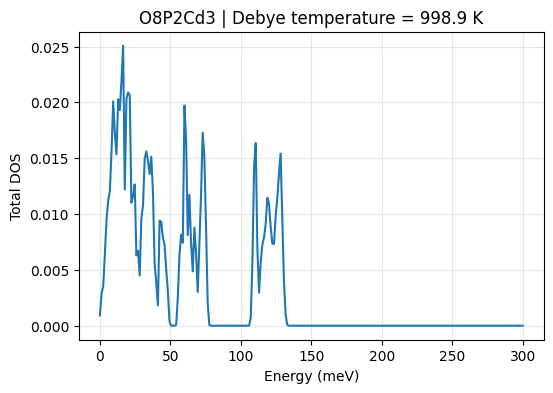

In [54]:
sample = train_df.sample(1, random_state=30).iloc[0]
dos_table = load_dos_table(Path(sample["csv_path"]).with_name("vis_dos.csv"))
energy_grid, dos_curve = resample_dos_curve(
    dos_table["E"].to_numpy(dtype=np.float32),
    dos_table["Total_DOS"].to_numpy(dtype=np.float32),
    n_points=256,
)

plt.figure(figsize=(6, 4))
plt.plot(energy_grid, dos_curve)
plt.title(f"{sample['formula']} | Debye temperature = {sample['debye_temperature_K']:.1f} K")
plt.xlabel("Energy (meV)")
# plt.xscale('log')
plt.ylabel("Total DOS")
plt.grid(alpha=0.3)
plt.show()

## Preprocessing the DOS

Neural networks need inputs with the same size, so every DOS is interpolated onto a fixed grid. We will set this with the variable `DOS_POINTS`.

we will also apply two common transformations:

$$x_{log} = \log(1 + x)$$

This compresses very large intensities and makes the scale easier to learn.

$$x_{norm} = (x - μ) / σ$$

Here `μ` and `σ` are computed from the **training set only**.
This is the usual z-score normalization and helps optimization behave more stably.


In [55]:
BATCH_SIZE = 32
train_dos_paths = [Path(path).with_name("vis_dos.csv") for path in train_df["csv_path"]]
test_dos_paths = [Path(path).with_name("vis_dos.csv") for path in test_df["csv_path"]]

DOS_POINTS = 256
mean, std = compute_dos_stats(train_dos_paths, n_points=DOS_POINTS, base_transform="log1p")
X_train = make_dos_tensor(train_dos_paths, n_points=DOS_POINTS, base_transform="log1p", mean=mean, std=std)
X_test = make_dos_tensor(test_dos_paths, n_points=DOS_POINTS, base_transform="log1p", mean=mean, std=std)

y_train = torch.tensor(train_df["debye_temperature_K"].to_numpy(), dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(test_df["debye_temperature_K"].to_numpy(), dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print("Input tensor shape:", tuple(X_train.shape))


Input tensor shape: (800, 256)


## Regression Model and Loss

We use a small multilayer perceptron (MLP):

$$ŷ = f_w(x)$$

where:
- $x$ is the normalized DOS vector
- $w$ are the trainable weights
- $ŷ$ is the predicted Debye temperature

During training we minimize the mean squared error loss function:

$$MSE = \frac{1}{N} \sum_i (ŷ_i - y_i)^2$$

We also report the mean absolute error:

$$MAE = \frac{1}{N} \sum_i |ŷ_i - y_i|$$

`MAE` is often easier to interpret because it is expressed directly in Kelvin.


In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(DOS_POINTS, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)

LR = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
loss_fn = nn.MSELoss()

def run_epoch(loader, training):
    model.train(training)
    preds = []
    targets = []
    total_loss = 0.0
    total_items = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        with torch.set_grad_enabled(training):
            pred = model(xb)
            loss = loss_fn(pred, yb)
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        preds.append(pred.detach().cpu())
        targets.append(yb.detach().cpu())
        total_loss += loss.item() * len(xb)
        total_items += len(xb)

    preds = torch.cat(preds).squeeze(1).numpy()
    targets = torch.cat(targets).squeeze(1).numpy()
    mae = np.mean(np.abs(preds - targets))
    return total_loss / total_items, mae, preds, targets

history = []
EPOCHS = 50
for epoch in range(1, EPOCHS + 1):
    train_loss, train_mae, _, _ = run_epoch(train_loader, training=True)
    test_loss, test_mae, _, _ = run_epoch(test_loader, training=False)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "test_mae": test_mae,
        }
    )
    
    print(
        f"epoch {epoch:02d} | train_loss={train_loss:.3f} | "
        f"test_loss={test_loss:.3f} | test_mae={test_mae:.2f} K"
    )

history_df = pd.DataFrame(history)
history_df


epoch 01 | train_loss=598055.068 | test_loss=570848.115 | test_mae=661.97 K
epoch 02 | train_loss=579171.618 | test_loss=530139.660 | test_mae=641.06 K
epoch 03 | train_loss=502503.607 | test_loss=404830.486 | test_mae=570.40 K
epoch 04 | train_loss=334489.966 | test_loss=207803.599 | test_mae=413.41 K
epoch 05 | train_loss=157946.948 | test_loss=114532.285 | test_mae=286.17 K
epoch 06 | train_loss=95996.586 | test_loss=92690.744 | test_mae=242.90 K
epoch 07 | train_loss=67993.071 | test_loss=70526.561 | test_mae=200.14 K
epoch 08 | train_loss=48820.656 | test_loss=58210.353 | test_mae=175.82 K
epoch 09 | train_loss=37318.166 | test_loss=50409.960 | test_mae=164.39 K
epoch 10 | train_loss=31204.575 | test_loss=45803.918 | test_mae=155.93 K
epoch 11 | train_loss=26528.796 | test_loss=41721.262 | test_mae=147.79 K
epoch 12 | train_loss=22770.082 | test_loss=39037.748 | test_mae=139.39 K
epoch 13 | train_loss=19957.238 | test_loss=36743.266 | test_mae=133.27 K
epoch 14 | train_loss=17789.

,epoch,train_loss,test_loss,test_mae
0,1,598055.067500,570848.115000,661.973694
1,2,579171.617500,530139.660000,641.059692
2,3,502503.607500,404830.486250,570.397095
3,4,334489.966250,207803.598750,413.414215
4,5,157946.948125,114532.284687,286.171356
5,6,95996.586406,92690.744063,242.899368
6,7,67993.070703,70526.560938,200.141388
7,8,48820.656484,58210.353438,175.817383
8,9,37318.165703,50409.960469,164.392975
9,10,31204.574531,45803.917813,155.930923


## How To Read the Final Plot

The parity plot compares:
- horizontal axis: true Debye temperature
- vertical axis: predicted Debye temperature

If all points were exactly on the diagonal, the model would be perfect.
The spread around that line shows the prediction error.


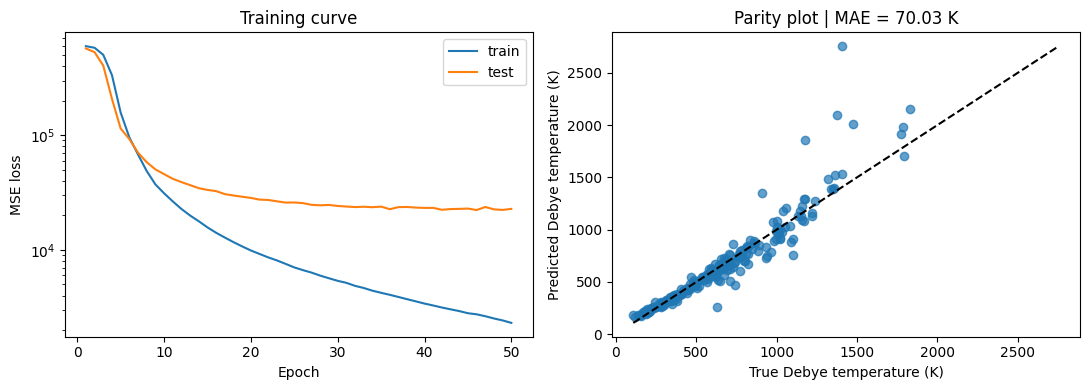

In [65]:
_, test_mae, test_pred, test_true = run_epoch(test_loader, training=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["test_loss"], label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Training curve")
axes[0].set_yscale('log')
axes[0].legend()

axes[1].scatter(test_true, test_pred, alpha=0.7)
lo = min(test_true.min(), test_pred.min())
hi = max(test_true.max(), test_pred.max())
axes[1].plot([lo, hi], [lo, hi], "--", color="black")
axes[1].set_xlabel("True Debye temperature (K)")
axes[1].set_ylabel("Predicted Debye temperature (K)")
axes[1].set_title(f"Parity plot | MAE = {test_mae:.2f} K")

plt.tight_layout()
plt.show()


## Conclusion

In this notebook we built a simple regression pipeline for neutron-scattering data. We extracted a Debye-temperature target from each crystal’s total DOS, converted every DOS curve into a fixed-length, normalized input vector, trained a small PyTorch MLP, and evaluated the result with loss curves and a parity plot.

In this tutorial, we have seen that:
- raw spectral data can be converted into ML inputs with interpolation and normalization,
- a Multi Layer Perceptron neural network can learn a scalar materials property from the DOS,
- the full workflow includes data loading, preprocessing, train/test splitting, modeling, training, and evaluation.

This is a compact, practical example of how machine learning can be applied to neutron-science data. A natural next step is to compare other input representations, try a larger model, change the target, or extend the task to classification over crystal systems.